# Homework 2: Convolutional Neural Networks for Image Analysis


In [4]:
import pickle
import numpy as np
import torch
import torch.nn
import torchmetrics as tm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

import deeplay as dl

torch.manual_seed(42)
np.random.seed(42)

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
# Load datasets
with open('simple_particle_dataset.pkl', 'rb') as f:
    simple_data = pickle.load(f)
    
with open('hard_particle_dataset.pkl', 'rb') as f:
    hard_data = pickle.load(f)

# Convert lists to numpy arrays
simple_data['images'] = np.array(simple_data['images'])
simple_data['labels'] = np.array(simple_data['labels'])
hard_data['images']   = np.array(hard_data['images'])
hard_data['labels']   = np.array(hard_data['labels'])

# We should normalise the inputs, this way we can center the data at 0 so the network learn faster
hard_mean = hard_data['images'].mean()
hard_std  = hard_data['images'].std()
hard_data['images'] = (hard_data['images'] - hard_mean) / hard_std

print(f"Simple dataset: images {simple_data['images'].shape}, labels {simple_data['labels'].shape}")
print(f"Hard dataset:   images {hard_data['images'].shape}, labels {hard_data['labels'].shape}")

Simple dataset: images (10000, 64, 64), labels (10000, 3)
Hard dataset:   images (12000, 64, 64), labels (12000, 3)


In [6]:
def make_split(data_dict, split=(0.7, 0.15, 0.15)):
    """Split dataset into train/val/test."""
    images = data_dict['images']
    labels = data_dict['labels']
    n = len(images)
    
    # Random permutation
    idx = np.random.permutation(n)
    
    # Split indices
    n_train = int(n * split[0])
    n_val = int(n * split[1])
    
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    
    return (
        images[train_idx], labels[train_idx],
        images[val_idx], labels[val_idx],
        images[test_idx], labels[test_idx]
    )

class ImageDataset(Dataset): #tells the data loader the the format and ow many samples we have
    """Dataset wrapper for image and label tensors."""
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)#Converts the numpy image array to a float32 tensor. Float32 is needed because neural networks use 32-bit floats for computation.
        if self.images.dim() == 3: 
            self.images = self.images.unsqueeze(1)  # (N, 64, 64) -> (N, 1, 64, 64)
        self.labels = torch.tensor(labels, dtype=torch.float32) #Converts labels to float32. Needed for BCELoss which expects float targets.
    
    def __len__(self):
        return len(self.images) #Returns the total number of samples. The DataLoader calls this to know how many batches to create.
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx] #Returns one sample by index. The DataLoader calls this repeatedly with different indices to assemble each batch. 

## Question 1: Binary Classification (Simple Dataset)

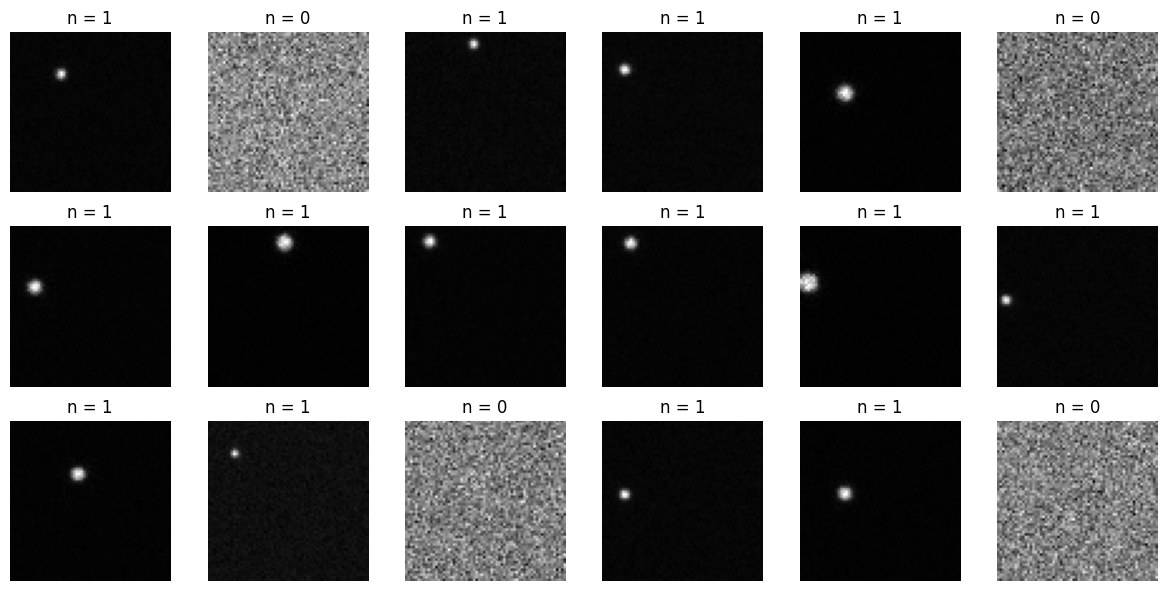

In [7]:
def plot_particles(images, labels):
    fig, axs = plt.subplots(3, 6, figsize=(12, 6))

    for ax in axs.ravel():
        i = np.random.randint(0, len(images))
        image = images[i]
        label = labels[i]

        ax.imshow(image, cmap="gray")
        ax.set_title(f"n = {int(label[0])}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

simple_images = simple_data['images']
simple_labels = simple_data['labels']
plot_particles(simple_images,simple_labels)

In [ ]:
# Q1: Binary classification data
simple_train_x, simple_train_y, simple_val_x, simple_val_y, simple_test_x, simple_test_y = make_split(simple_data)

# For binary classification, create dataset with binary labels (num_particles: 0 or 1)
q1_train_labels = simple_train_y[:, 0:1]  # Shape (N, 1) - binary class
q1_val_labels = simple_val_y[:, 0:1]
q1_test_labels = simple_test_y[:, 0:1] 

#create each dataset
q1_train_dataset = ImageDataset(simple_train_x, q1_train_labels)
q1_val_dataset = ImageDataset(simple_val_x, q1_val_labels)
q1_test_dataset = ImageDataset(simple_test_x, q1_test_labels)

#use loaders to load the data
q1_train_loader = DataLoader(q1_train_dataset, batch_size=32, shuffle=True)
q1_val_loader = DataLoader(q1_val_dataset, batch_size=32, shuffle=False)
q1_test_loader = DataLoader(q1_test_dataset, batch_size=32, shuffle=False)

print(f"Q1 Train: {len(q1_train_dataset)}, Val: {len(q1_val_dataset)}, Test: {len(q1_test_dataset)}")

Q1 Train: 7000, Val: 1500, Test: 1500


In [20]:
print(q1_train_labels.shape,q1_val_labels.shape,q1_test_labels.shape)
print(q1_train_dataset.images[0].shape)


(7000, 1) (1500, 1) (1500, 1)
torch.Size([1, 64, 64])


In [ ]:
def build_q1_model(arch_name, in_channels=1):
    #(batch_size, channels, height, width)
    if arch_name == 'Large':
        conv_base = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels,
            hidden_channels=[16, 16],
            out_channels=32,
            out_activation=torch.nn.ReLU
        )
        conv_base.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        out_ch = 32  
        #(B, 32, H/2, W/2)

    elif arch_name == 'Medium':
        conv_base = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels,
            hidden_channels=[16],
            out_channels=32,
            out_activation=torch.nn.ReLU
        )
        conv_base.blocks[1].pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        out_ch = 32
        #(B, 32, H/2, W/2)

    elif arch_name == 'Small':
        conv_base = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels,
            hidden_channels=[1],
            out_channels=4,
            out_activation=torch.nn.ReLU
        )
        conv_base.blocks[0].pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        out_ch = 4
        #(B, 4, H/2, W/2)
        
    elif arch_name == 'Minimal':
        conv_base = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels,
            hidden_channels=[1],
            out_channels=1,
           
        )
        conv_base.blocks[0].pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        out_ch = 1
        #(B, 1, H/2, W/2)

    connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)
    #(B,channels,1,1)

    dense_top = dl.MultiLayerPerceptron( #implicitly flattens
        in_features=out_ch,
        hidden_features=[],
        out_features=1,
        out_activation=torch.nn.Sigmoid
    )
    #(B,1)


    model = dl.Sequential(conv_base, connector, dense_top) # chains the three components into a single model so data flows through them in order:

    classifier = dl.BinaryClassifier( #This compiles the model into a fully trainable object.
        model=model,
        optimizer=dl.Adam(lr=0.001) #uses 1rst and second moment to compute the gradients
    ).create()

    return classifier

# Test architecture building
test_model = build_q1_model('Large')
print("Q1 Large architecture:")
print(test_model)

Q1 Large architecture:
BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
  

In [ ]:
def train_and_evaluate_q1(arch_name, max_epochs=10):
    print(f"Q1 Architecture: {arch_name}")
    
    # Build model
    classifier = build_q1_model(arch_name)
    
    # Print architecture
    print(f"\nModel architecture:")
    print(classifier)
    
    # Train
    trainer = dl.Trainer(max_epochs=max_epochs, accelerator='auto')
    trainer.fit(classifier, q1_train_loader, q1_val_loader) #train on train and val data
    
    # Evaluate F1 and ROC
    classifier.eval() #Set the module in evaluation mode.
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  #so it no computes gradients, only the metrics
        for images, labels in q1_test_loader: #iterates over the test set in batches and their corresponding labels
            preds = classifier(images)  # Shape (N, 1). Passes each batch through the model to get predictions (probabilities)
            all_preds.append(preds.numpy()) #stores predictions on each batch and converts to Numpy because the f1 score expects numpy arrays
            all_labels.append(labels.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0).flatten() #shape (1500,)
    all_labels = np.concatenate(all_labels, axis=0).flatten()
    
    
    # F1 score
    f1 = f1_score(all_labels, (all_preds > 0.5).astype(int)) #Converts predicted probabilities into class labels(True,False) and then it converts them into 0 or 1
    print(f"\nF1 Score: {f1:.4f}")
    
    # ROC curve
    roc = tm.ROC(task='binary')
    roc.update( #changes data types
        torch.tensor(all_preds, dtype=torch.float32), 
        torch.tensor(all_labels, dtype=torch.long)
    )
    
    fig, ax = roc.plot(score=True)
    ax.grid(False)
    ax.axis('square')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'Q1 ROC Curve - {arch_name}')
    plt.tight_layout()
    plt.show()
    
    return f1

print("Q1 training function defined.")

Q1 training function defined.


Q1 Architecture: Large

Model architecture:
BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
     

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  7.2 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 26                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 9: 100%|██████████| 219/219 [00:04<00:00, 49.33it/s, v_num=50, train_loss_step=4.57e-7, trainBinaryAccuracy_step=1.000, val_loss_step=4.6e-7, valBinaryAccuracy_step=1.000, val_loss_epoch=6.29e-7, valBinaryAccuracy_epoch=1.000, train_loss_epoch=8.38e-7, trainBinaryAccuracy_epoch=1.000]  

F1 Score: 1.0000


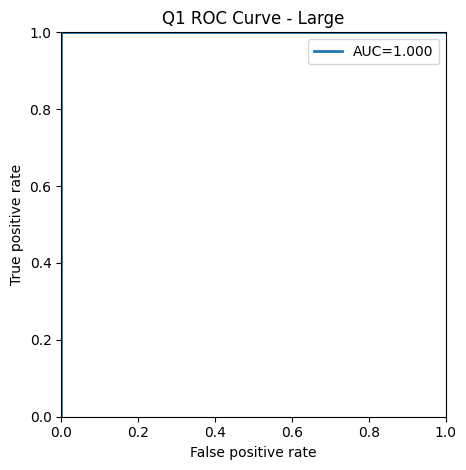

Large        - F1: 1.0000


In [130]:
q1_results = {}
f1 = train_and_evaluate_q1('Large', max_epochs=10)
q1_results['Large'] = f1

print(f"{'Large':12} - F1: {f1:.4f}")

Q1 Architecture: Medium

Model architecture:
BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
    (1): AdaptiveAvgPool2d(output_size=1)
    (2): MultiLayerPerceptron(
      (blocks): LayerList(
        (0): LinearBlock(
      

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  4.8 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 9: 100%|██████████| 219/219 [00:03<00:00, 60.68it/s, v_num=39, train_loss_step=3.18e-5, trainBinaryAccuracy_step=1.000, val_loss_step=4.18e-5, valBinaryAccuracy_step=1.000, val_loss_epoch=3.96e-5, valBinaryAccuracy_epoch=1.000, train_loss_epoch=4.7e-5, trainBinaryAccuracy_epoch=1.000]     

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 47/47 [00:00<00:00, 95.67it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testBinaryAccuracy_epoch  │            1.0            │
│      test_loss_epoch      │   3.840144199784845e-05   │
└───────────────────────────┴───────────────────────────┘


F1 Score: 1.0000


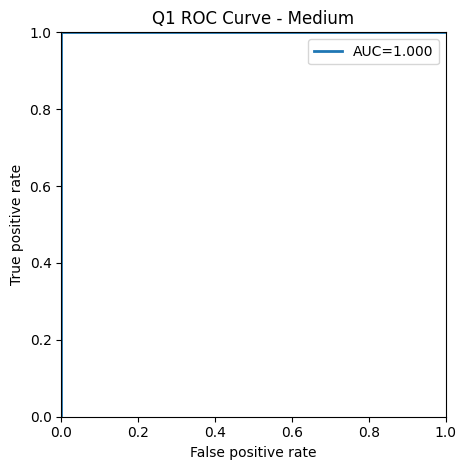

Medium - F1: 1.0000


In [97]:
q1_results = {}
f1 = train_and_evaluate_q1('Medium', max_epochs=10)
q1_results['Medium'] = f1

print(f"{'Medium'} - F1: {f1:.4f}")

Q1 Architecture: Small

Model architecture:
BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
    (1): AdaptiveAvgPool2d(output_size=1)
    (2): MultiLayerPerceptron(
      (blocks): LayerList(
        (0): LinearBlock(
          

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │     55 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 55                                                                                               
Non-trainable params: 0                                                                                            
Total params: 55                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 9: 100%|██████████| 219/219 [00:03<00:00, 61.77it/s, v_num=52, train_loss_step=0.00373, trainBinaryAccuracy_step=1.000, val_loss_step=0.00301, valBinaryAccuracy_step=1.000, val_loss_epoch=0.00399, valBinaryAccuracy_epoch=1.000, train_loss_epoch=0.00459, trainBinaryAccuracy_epoch=1.000]

F1 Score: 1.0000


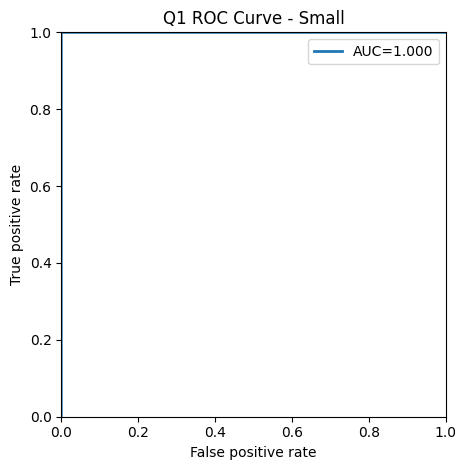

Small        - F1: 1.0000


In [132]:
q1_results = {}
f1 = train_and_evaluate_q1('Small', max_epochs=10)
q1_results['Small'] = f1

print(f"{'Small':12} - F1: {f1:.4f}")

Q1 Architecture: Minimal

Model architecture:
BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): Identity()
        )
      )
    )
    (1): AdaptiveAvgPool2d(output_size=1)
    (2): MultiLayerPerceptron(
      (blocks): LayerList(
        (0): LinearBlock(
    

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │     22 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 22                                                                                               
Non-trainable params: 0                                                                                            
Total params: 22                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 219/219 [00:06<00:00, 34.35it/s, v_num=54, train_loss_step=0.015, trainBinaryAccuracy_step=1.000, val_loss_step=0.016, valBinaryAccuracy_step=1.000, val_loss_epoch=0.0152, valBinaryAccuracy_epoch=1.000, train_loss_epoch=0.0173, trainBinaryAccuracy_epoch=1.000]   

F1 Score: 1.0000


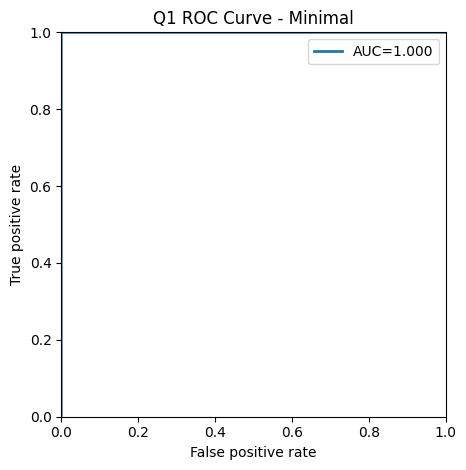

Minimal      - F1: 1.0000


In [10]:
q1_results = {}
f1 = train_and_evaluate_q1('Minimal', max_epochs=10)
q1_results['Minimal'] = f1

print(f"{'Minimal':12} - F1: {f1:.4f}")

## Question 2: Multiclass Classification (Hard Dataset)


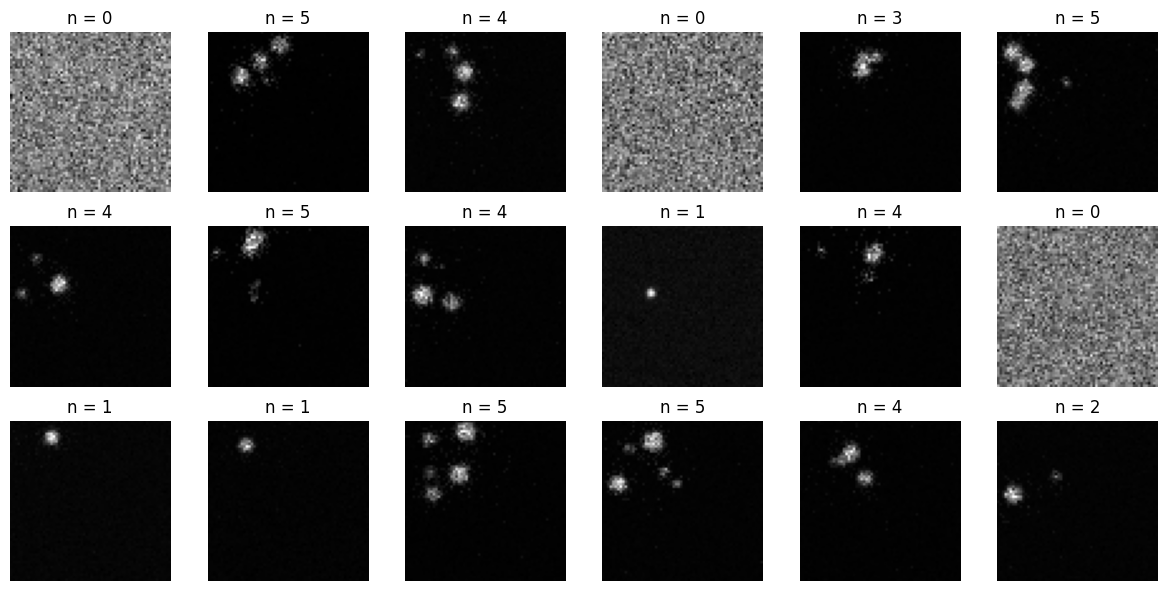

In [36]:
hard_images = hard_data['images']
hard_labels = hard_data['labels']
plot_particles(hard_images,hard_labels)

In [ ]:
# Q2: Multiclass classification data
hard_train_x, hard_train_y, hard_val_x, hard_val_y, hard_test_x, hard_test_y = make_split(hard_data)

# For multiclass classification, use num_particles (0-5) as labels
# Convert to long type for CrossEntropyLoss
q2_train_labels = hard_train_y[:, 0].astype(np.int64)  # Shape (N,)
q2_val_labels = hard_val_y[:, 0].astype(np.int64)
q2_test_labels = hard_test_y[:, 0].astype(np.int64)


# I reuse ImageDataset but force labels to long after creation
q2_train_dataset = ImageDataset(hard_train_x, q2_train_labels)
q2_train_dataset.labels = q2_train_dataset.labels.long()  # float32 → int64

q2_val_dataset = ImageDataset(hard_val_x, q2_val_labels)
q2_val_dataset.labels = q2_val_dataset.labels.long()

q2_test_dataset = ImageDataset(hard_test_x, q2_test_labels)
q2_test_dataset.labels = q2_test_dataset.labels.long()

q2_train_loader = DataLoader(q2_train_dataset, batch_size=32, shuffle=True)
q2_val_loader = DataLoader(q2_val_dataset, batch_size=32, shuffle=False)
q2_test_loader = DataLoader(q2_test_dataset, batch_size=32, shuffle=False)

print(f"Q2 Train: {len(q2_train_dataset)}, Val: {len(q2_val_dataset)}, Test: {len(q2_test_dataset)}")
print(f"Number of classes: 6 (particles 0-5)")

Q2 Train: 8400, Val: 1800, Test: 1800
Number of classes: 6 (particles 0-5)


In [98]:
print(q2_train_labels.shape,q2_val_labels.shape,q2_test_labels.shape)

(8400,) (1800,) (1800,)


In [ ]:
def build_q2_model(arch_name, in_channels=1, num_classes=6):

    if arch_name == 'Architecture 1':
    # Follows Q1 Large style: only the last block gets pooling,
    # then AdaptiveAvgPool collapses spatial dims to (1,1). It scores low because AdaptiveAvgPool destroys the spatial information needed to count particles
    # Block 0: Conv(1->32),  no pool -> (B, 32, 64, 64)
    # Block 1: Conv(32->32), no pool -> (B, 32, 64, 64)
    # Block 2: Conv(32->64) + pool   -> (B, 64, 32, 32)
    # AdaptiveAvgPool(1)            -> (B, 64,  1,  1)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[32, 32], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        conv.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

        cnn = dl.Sequential(
            conv,
            dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1),  # same as Q1 Large
            dl.Layer(torch.nn.Flatten),
            dl.MultiLayerPerceptron(
                in_features=64,           # (B, 64) after flatten
                hidden_features=[64],
                out_features=num_classes,
                out_activation=torch.nn.Identity
            )
        )
        classifier = dl.Classifier(model=cnn, optimizer=dl.Adam(lr=0.001)).create()
        return classifier
    
    elif arch_name == 'Architecture 2':
        # Block 0: Conv(1->16) + pool -> (B, 16, 32, 32)
        # Block 1: Conv(16->32) + pool -> (B, 32, 16, 16)
        # Block 2: Conv(32->64) + pool -> (B, 64,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[16, 32], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 64*8*8 #4096
        #(B, 64, H/8, W/8)

    
    elif arch_name == 'Architecture 3':
        # Block 0: Conv(1->8) + pool -> (B,  8, 32, 32)
        # Block 1: Conv(8->16) + pool -> (B, 16, 16, 16)
        # Block 2: Conv(16->32) + pool -> (B, 32,  8,  8)
        # Block 3: Conv(32->64) + pool -> (B, 64,  4,  4)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[8, 16, 32], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 64*4*4 #1024

    cnn = dl.Sequential(
        conv,
        dl.Layer(torch.nn.Flatten), #connector. (B, 64, 8, 8) -> (B, 4096) collapses spatial dims into one vector (in first case)
        dl.MultiLayerPerceptron(
            in_features=in_feat, # flat vector of all spatial features
            hidden_features=[256,128], # hidden layer: (B, 4096) -> (B, 128)
            out_features=num_classes, # output: (B, 128) -> (B, 6) one score per class
            out_activation=torch.nn.Identity 
            # Identity means NO activation on the output
            # dl.Classifier uses CrossEntropyLoss internally, which applies log-softmax itself. If we added Softmax here, it would be applied twice.
        )
    )

    classifier = dl.Classifier(
        model=cnn, optimizer=dl.Adam(lr=0.001)
    ).create()

    return classifier

# Test architecture building
test_model = build_q2_model('Architecture 1')
print("Q2 Architecture 1:")
print(test_model)

Q2 Architecture 1:
Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
    (1): AdaptiveAvgPool2d(output_size=1)
    (2): Flatten(start_dim=1, end_dim=-1)
   

In [ ]:
def train_and_evaluate_q2(arch_name, max_epochs=50):
    """Train Q2 model and report F1 score."""
    print(f"\n{'='*60}")
    print(f"Q2 {arch_name}")
    print(f"{'='*60}")
    
    # Build model
    classifier = build_q2_model(arch_name)
    
    # Print architecture
    print(f"\nModel architecture:")
    print(classifier)
    
    # Train
    trainer = dl.Trainer(max_epochs=max_epochs, accelerator='auto')
    trainer.fit(classifier, q2_train_loader, q2_val_loader)
    
    # Evaluate F1
    classifier.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in q2_test_loader:
            logits = classifier(images)  # Shape (B, 6)
            preds = torch.argmax(logits, dim=1) #take the dimension that has highest value. They can be any real value
            all_preds.append(preds.numpy()) #convert to numpy array so the f1 score doesnt give error
            all_labels.append(labels.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0) #merges all the batches  into one flat array. shape (N,)
    all_labels = np.concatenate(all_labels, axis=0)
    
    # F1 score (macro average for multiclass)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\nF1 Score (macro): {f1:.4f}")
    
    return f1

print("Q2 training function defined.")

Q2 training function defined.


In [28]:
q2_results = {}
f1 = train_and_evaluate_q2('Architecture 1')
q2_results['Architecture 1'] = f1

print(f"{'Architecture 1':20} - F1: {f1:.4f}")


Q2 Architecture 1

Model architecture:
Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
    (1): AdaptiveAvgPool2d(output_size=1)
    (2): Flatten(start_d

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │ 32.6 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 32.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 32.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 9: 100%|██████████| 263/263 [00:05<00:00, 52.54it/s, v_num=58, train_loss_step=1.790, val_loss_step=1.810, val_loss_epoch=1.790, train_loss_epoch=1.790]


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 57/57 [00:00<00:00, 101.61it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │     1.792772889137268     │
└───────────────────────────┴───────────────────────────┘


F1 Score (macro): 0.1169
Architecture 1       - F1: 0.1169


In [101]:
q2_results = {}
f1 = train_and_evaluate_q2('Architecture 2')
q2_results['Architecture 2'] = f1

print(f"{'Architecture 2':20} - F1: {f1:.4f}")


Q2 Architecture 2

Model architecture:
Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): C

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  1.1 M │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 17.38it/s]

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 49: 100%|██████████| 263/263 [00:03<00:00, 69.63it/s, v_num=72, train_loss_step=0.625, val_loss_step=0.951, val_loss_epoch=0.777, train_loss_epoch=0.756] 

F1 Score (macro): 0.6392
Architecture 2       - F1: 0.6392


In [43]:
q2_results = {}
f1 = train_and_evaluate_q2('Architecture 3')
q2_results['Architecture 3'] = f1

print(f"{'Architecture 3':20} - F1: {f1:.4f}")


Q2 Architecture 3

Model architecture:
Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Con

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  320 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 320 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 320 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 49: 100%|██████████| 263/263 [00:04<00:00, 55.66it/s, v_num=63, train_loss_step=1.010, val_loss_step=0.353, val_loss_epoch=0.813, train_loss_epoch=0.753]


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 57/57 [00:00<00:00, 105.35it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │    0.8136186003684998     │
└───────────────────────────┴───────────────────────────┘


F1 Score (macro): 0.6178
Architecture 3       - F1: 0.6178


## Question 3: Localization on Simple Dataset


In [27]:
# Q3: Localization data (only 1 particle images)
mask = simple_data['labels'][:, 0] == 1  # Keep only 1 particle images
simple_one_particle = {
    'images': simple_data['images'][mask],
    'labels': simple_data['labels'][mask]
}

print(f"Q3 data: {simple_one_particle['images'].shape} (only 1 particle images)")

# Split
q3_train_x, q3_train_y, q3_val_x, q3_val_y, q3_test_x, q3_test_y = make_split(simple_one_particle)

# Extract positions (x, y) and normalize to [0, 1]
q3_train_pos = q3_train_y[:, 1:3] / 64.0  # Extract x and y and Normalize 
q3_val_pos = q3_val_y[:, 1:3] / 64.0
q3_test_pos = q3_test_y[:, 1:3] / 64.0

# Create dataset
q3_train_dataset = ImageDataset(q3_train_x, q3_train_pos)
q3_val_dataset = ImageDataset(q3_val_x, q3_val_pos)
q3_test_dataset = ImageDataset(q3_test_x, q3_test_pos)

q3_train_loader = DataLoader(q3_train_dataset, batch_size=32, shuffle=True)
q3_val_loader = DataLoader(q3_val_dataset, batch_size=32, shuffle=False)
q3_test_loader = DataLoader(q3_test_dataset, batch_size=32, shuffle=False)

print(f"Q3 Train: {len(q3_train_dataset)}, Val: {len(q3_val_dataset)}, Test: {len(q3_test_dataset)}")
print(f"X range: {q3_train_pos[:, 0].min():.3f} to {q3_train_pos[:, 0].max():.3f}")
print(f"Y range: {q3_train_pos[:, 1].min():.3f} to {q3_train_pos[:, 1].max():.3f}")

Q3 data: (5000, 64, 64) (only 1 particle images)
Q3 Train: 3500, Val: 750, Test: 750
X range: 0.032 to 0.469
Y range: 0.031 to 0.469


In [28]:
print(q3_train_pos.shape,q3_val_pos.shape,q3_test_pos.shape)

(3500, 2) (750, 2) (750, 2)


In [29]:
def build_q3_model(arch_name, in_channels=1):

    if arch_name == 'Architecture 1':
        # Input:   (B,  1, 64, 64)
        # Block 0: Conv(1->16)  + pool -> (B, 16, 32, 32)
        # Block 1: Conv(16->32) + pool -> (B, 32, 16, 16)
        # Block 2: Conv(32->64) + pool -> (B, 64,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[16, 32], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 64*8*8  # 4096

    elif arch_name == 'Architecture 2':
        # Input:   (B,  1, 64, 64)
        # Block 0: Conv(1->32)  + pool -> (B, 32, 32, 32)
        # Block 1: Conv(32->64) + pool -> (B, 64, 16, 16)
        # Block 2: Conv(64->64) + pool -> (B, 64,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[32, 64], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 64*8*8  # 4096

    elif arch_name == 'Architecture 3':
        # Input:   (B,  1, 64, 64)
        # Block 0: Conv(1->8)   + pool -> (B,  8, 32, 32)
        # Block 1: Conv(8->16)  + pool -> (B, 16, 16, 16)
        # Block 2: Conv(16->32) + pool -> (B, 32,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[8, 16], out_channels=32,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 32*8*8  # 2048
    
    elif arch_name == 'Architecture 4 (Minimal)':
        # Input:   (B, 1, 64, 64)
        # Block 0: Conv(1->4) + pool(4) -> (B, 4, 16, 16)
        # Flatten                        -> (B, 1024)
        # Linear(1024->4)                -> (B, 4)
        # Linear(4->2)                   -> (B, 2)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=1, hidden_channels=[], out_channels=1,
            out_activation=torch.nn.ReLU
        )
        conv.blocks[0].pool.configure(torch.nn.MaxPool2d, kernel_size=4)
        in_feat = 1*16*16  # 1024

        cnn = dl.Sequential(
            conv,
            dl.Layer(torch.nn.Flatten),
            dl.MultiLayerPerceptron(
                in_features=in_feat,
                hidden_features=[],
                out_features=2,
                out_activation=torch.nn.Identity
            )
        )
        regressor = dl.Regressor(
            model=cnn, loss=torch.nn.MSELoss(),
            optimizer=dl.Adam(lr=0.001), metrics=[tm.MeanAbsoluteError()]
        ).create()
        return regressor

    cnn = dl.Sequential(
        conv,
        dl.Layer(torch.nn.Flatten),       # (B, 64, 8, 8) -> (B, 4096) for arch 1&2, (B, 32, 8, 8) -> (B, 2048) for arch 3
        dl.MultiLayerPerceptron(
            in_features=in_feat,          # 4096 or 2048 depending on architecture
            hidden_features=[32, 32],     # (B, in_feat) -> (B, 32) -> (B, 32)
            out_features=2,               # (B, 32) -> (B, 2)  one value for x, one for y
            out_activation=torch.nn.Identity  # no activation: output is raw (x, y) coordinates in [0,1]
        )
    )

    regressor = dl.Regressor(
        model=cnn, loss=torch.nn.MSELoss(),  # MSE between predicted (x,y) and true (x,y)
        optimizer=dl.Adam(lr=0.001), metrics=[tm.MeanAbsoluteError()]
    ).create()

    return regressor

# Test architecture building
test_model = build_q3_model('Architecture 1')
print("Q3 Architecture 1:")
print(test_model)

Q3 Architecture 1:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
      

In [33]:
def train_and_evaluate_q3(arch_name, max_epochs=30):
    """Train Q3 regression model and report MAE."""
    print(f"\n{'='*60}")
    print(f"Q3 {arch_name}")
    print(f"{'='*60}")
    
    # Build model
    regressor = build_q3_model(arch_name)
    
    # Print architecture
    print(f"\nModel architecture:")
    print(regressor)
    
    # Train
    trainer = dl.Trainer(max_epochs=max_epochs, accelerator='auto')
    trainer.fit(regressor, q3_train_loader, q3_val_loader)
    
    #  Test on held-out test set. returns a list of dicts with metric values
    results = trainer.test(regressor, q3_test_loader) #results is a dictionary, position 0 is the metrics
    
    # Extract MAE (convert from normalized to pixels)
    mae_normalized = results[0]['testMeanAbsoluteError_epoch']# The MAE metric was computed on normalized positions (divided by 64 when we built the dataset)so it measures error in the [0, 1] range, not in pixels
    mae_pixels = mae_normalized * 64  # Convert to pixel scale
    #Why normalize in the first place then? Because training is more stable when targets are in [0, 1]
    print(f"\nMAE (normalized): {mae_normalized:.4f}")
    print(f"MAE (pixels):     {mae_pixels:.4f}")
    
    return mae_pixels

print("Q3 training function defined.")

Q3 training function defined.


In [34]:
q3_results = {}
mae = train_and_evaluate_q3('Architecture 1', max_epochs=50)
q3_results['Architecture 1'] = mae

print(f"{'Architecture 1':20} - MAE: {mae:.4f} pixels")


Q3 Architecture 1

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  155 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 155 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 155 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Testing DataLoader 0: 100%|██████████| 24/24 [00:00<00:00, 109.70it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.0025646674912422895    │
│       test_loss_epoch       │   1.0309908248018473e-05    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0026
MAE (pixels):     0.1641
Architecture 1       - MAE: 0.1641 pixels


In [58]:
q3_results = {}
mae = train_and_evaluate_q3('Architecture 2', max_epochs=50)
q3_results['Architecture 2'] = mae

print(f"{'Architecture 2':20} - MAE: {mae:.4f} pixels")


Q3 Architecture 2

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  187 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 187 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 187 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 110/110 [00:02<00:00, 42.34it/s, v_num=65, train_loss_step=3.78e-6, trainMeanAbsoluteError_step=0.00157, val_loss_step=2.09e-5, valMeanAbsoluteError_step=0.00351, val_loss_epoch=1.44e-5, valMeanAbsoluteError_epoch=0.00309, train_loss_epoch=7.64e-6, trainMeanAbsoluteError_epoch=0.00215]


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 24/24 [00:00<00:00, 72.10it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.003144522663205862     │
│       test_loss_epoch       │   1.4746186934644356e-05    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0031
MAE (pixels):     0.2012
Architecture 2       - MAE: 0.2012 pixels


In [59]:
q3_results = {}
mae = train_and_evaluate_q3('Architecture 3', max_epochs=50)
q3_results['Architecture 3'] = mae

print(f"{'Architecture 3':20} - MAE: {mae:.4f} pixels")


Q3 Architecture 3

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): 

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │ 72.6 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 72.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 72.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Testing DataLoader 0: 100%|██████████| 24/24 [00:00<00:00, 65.26it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.003550250083208084     │
│       test_loss_epoch       │   1.9498624169500545e-05    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0036
MAE (pixels):     0.2272
Architecture 3       - MAE: 0.2272 pixels


In [118]:

q3_results = {}
mae = train_and_evaluate_q3('Architecture 4 (Minimal)', max_epochs=50)
q3_results['Architecture 4 (Minimal)'] = mae

print(f"{'Architecture 4 (Minimal)':20} - MAE: {mae:.4f} pixels")


Q3 Architecture 4 (Minimal)

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
    )
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): MultiLayerPerceptron(
      (blocks): LayerList(
        (0): LinearBlock(
          (layer): Linear(in_features=256, out_features=2, bias=True)
          (activation): Identity()
  

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │    524 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 524                                                                                              
Non-trainable params: 0                                                                                            
Total params: 524                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Epoch 49: 100%|██████████| 110/110 [00:01<00:00, 78.96it/s, v_num=74, train_loss_step=0.000501, trainMeanAbsoluteError_step=0.0164, val_loss_step=0.000528, valMeanAbsoluteError_step=0.0184, val_loss_epoch=0.000597, valMeanAbsoluteError_epoch=0.0191, train_loss_epoch=0.000641, trainMeanAbsoluteError_epoch=0.0195] 


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 24/24 [00:00<00:00, 102.40it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │     0.01908295601606369     │
│       test_loss_epoch       │    0.0006174133741296828    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0191
MAE (pixels):     1.2213
Architecture 4 (Minimal) - MAE: 1.2213 pixels


## Question 4: Localization on Hard Dataset

In [103]:
# Q4: Localization on hard dataset (prune 0 particles)
mask = hard_data['labels'][:, 0] > 0  # Keep only images with >= 1 particle
hard_localization = {
    'images': hard_data['images'][mask],
    'labels': hard_data['labels'][mask]
}

print(f"Q4 data: {hard_localization['images'].shape} (only >= 1 particle images)")

# Split
q4_train_x, q4_train_y, q4_val_x, q4_val_y, q4_test_x, q4_test_y = make_split(hard_localization)

# Extract positions and normalize
q4_train_pos = q4_train_y[:, 1:3] / 64.0
q4_val_pos = q4_val_y[:, 1:3] / 64.0
q4_test_pos = q4_test_y[:, 1:3] / 64.0

# Create dataset
q4_train_dataset = ImageDataset(q4_train_x, q4_train_pos)
q4_val_dataset = ImageDataset(q4_val_x, q4_val_pos)
q4_test_dataset = ImageDataset(q4_test_x, q4_test_pos)

q4_train_loader = DataLoader(q4_train_dataset, batch_size=32, shuffle=True)
q4_val_loader = DataLoader(q4_val_dataset, batch_size=32, shuffle=False)
q4_test_loader = DataLoader(q4_test_dataset, batch_size=32, shuffle=False)

print(f"Q4 Train: {len(q4_train_dataset)}, Val: {len(q4_val_dataset)}, Test: {len(q4_test_dataset)}")

Q4 data: (10000, 64, 64) (only >= 1 particle images)
Q4 Train: 7000, Val: 1500, Test: 1500


In [ ]:
def build_q4_model(arch_name, in_channels=1):

    if arch_name == 'Architecture 1':
        # Input:   (B,   1, 64, 64)
        # Block 0: Conv(1->16)  + pool -> (B,  16, 32, 32)
        # Block 1: Conv(16->32) + pool -> (B,  32, 16, 16)
        # Block 2: Conv(32->64) + pool -> (B,  64,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[16, 32], out_channels=64,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 64*8*8   # 4096

    elif arch_name == 'Architecture 2':
        # Input:   (B,   1, 64, 64)
        # Block 0: Conv(1->32)   + pool -> (B,  32, 32, 32)
        # Block 1: Conv(32->64)  + pool -> (B,  64, 16, 16)
        # Block 2: Conv(64->128) + pool -> (B, 128,  8,  8)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[32, 64], out_channels=128,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 128*8*8  # 8192

    elif arch_name == 'Architecture 3':
        # Input:   (B,   1, 64, 64)
        # Block 0: Conv(1->16)  + pool -> (B,  16, 32, 32)
        # Block 1: Conv(16->32)  + pool -> (B,  32, 16, 16)
        # Block 2: Conv(32->64)   + pool -> (B,  64,  8,  8)
        # Block 3: Conv(64->128)  + pool -> (B, 128,  4,  4)
        conv = dl.ConvolutionalNeuralNetwork(
            in_channels=in_channels, hidden_channels=[16, 32, 64], out_channels=128,
            out_activation=torch.nn.ReLU
        )
        for block in conv.blocks:
            block.pool.configure(torch.nn.MaxPool2d, kernel_size=2)
        in_feat = 128*4*4  # 2048

    cnn = dl.Sequential(
        conv,
        dl.Layer(torch.nn.Flatten),          # collapses (B, C, H, W) -> (B, C*H*W)
        dl.MultiLayerPerceptron(
            in_features=in_feat,      
            hidden_features=[64, 32],        # (B, in_feat) -> (B, 64) -> (B, 32)
            out_features=2,                  # (B, 32) -> (B, 2): predicted (x, y) in [0,1]
            out_activation=torch.nn.Identity # no activation
        )
    )

    regressor = dl.Regressor(
        model=cnn, loss=torch.nn.MSELoss(),  # penalises distance between predicted and true (x,y)
        optimizer=dl.Adam(lr=0.001), metrics=[tm.MeanAbsoluteError()]
    ).create()

    return regressor
# Test architecture building
test_model = build_q4_model('Architecture 1')
print("Q4 Architecture 1:")
print(test_model)

Q4 Architecture 1:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
      

In [77]:
def train_and_evaluate_q4(arch_name, max_epochs=60):
    """Train Q4 regression model and report MAE."""
    print(f"\n{'='*60}")
    print(f"Q4 {arch_name}")
    print(f"{'='*60}")
    
    # Build model
    regressor = build_q4_model(arch_name)
    
    # Print architecture
    print(f"\nModel architecture:")
    print(regressor)
    
    # Train
    trainer = dl.Trainer(max_epochs=max_epochs, accelerator='auto')
    trainer.fit(regressor, q4_train_loader, q4_val_loader)
    
    # Test
    results = trainer.test(regressor, q4_test_loader)
    
    # Extract MAE
    mae_normalized = results[0]['testMeanAbsoluteError_epoch']
    mae_pixels = mae_normalized * 64
    
    print(f"\nMAE (normalized): {mae_normalized:.4f}")
    print(f"MAE (pixels):     {mae_pixels:.4f}")
    
    return mae_pixels

print("Q4 training function defined.")

Q4 training function defined.


In [105]:
q4_results = {}
mae = train_and_evaluate_q4('Architecture 1', max_epochs=60)
q4_results['Architecture 1'] = mae

print(f"{'Architecture 1':20} - MAE: {mae:.4f} pixels")


Q4 Architecture 1

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  287 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 287 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 287 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 219/219 [00:03<00:00, 65.60it/s, v_num=73, train_loss_step=0.00157, trainMeanAbsoluteError_step=0.0279, val_loss_step=0.000646, valMeanAbsoluteError_step=0.0193, val_loss_epoch=0.0018, valMeanAbsoluteError_epoch=0.0291, train_loss_epoch=0.00148, trainMeanAbsoluteError_epoch=0.0265]  


c:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 47/47 [00:00<00:00, 89.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.026809128001332283     │
│       test_loss_epoch       │    0.0015342897968366742    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0268
MAE (pixels):     1.7158
Architecture 1       - MAE: 1.7158 pixels


In [75]:
q4_results = {}
mae = train_and_evaluate_q4('Architecture 2', max_epochs=60)
q4_results['Architecture 2'] = mae

print(f"{'Architecture 2':20} - MAE: {mae:.4f} pixels")


Q4 Architecture 2

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  619 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 619 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 619 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Testing DataLoader 0: 100%|██████████| 47/47 [00:00<00:00, 68.62it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │    0.023660622537136078     │
│       test_loss_epoch       │    0.0013839927269145846    │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0237
MAE (pixels):     1.5143
Architecture 2       - MAE: 1.5143 pixels


In [78]:
q4_results = {}
mae = train_and_evaluate_q4('Architecture 3', max_epochs=60)
q4_results['Architecture 3'] = mae

print(f"{'Architecture 3':20} - MAE: {mae:.4f} pixels")


Q4 Architecture 3

Model architecture:
Regressor(
  (loss): MSELoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MeanAbsoluteError): MeanAbsoluteError(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  230 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 230 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 230 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Testing DataLoader 0: 100%|██████████| 47/47 [00:00<00:00, 108.09it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │     0.02339261583983898     │
│       test_loss_epoch       │    0.001391907804645598     │
└─────────────────────────────┴─────────────────────────────┘


MAE (normalized): 0.0234
MAE (pixels):     1.4971
Architecture 3       - MAE: 1.4971 pixels
